<a href="https://colab.research.google.com/github/HalimehAgh/llm-engineering-exercises/blob/main/exercises/exercise-7-synthetic-data-generation/notebooks/synthetic_data_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🎯 Synthetic Data Generation with Hugging Face




In [1]:
# Check if GPU is available
import torch

print("=" * 50)
print("GPU STATUS")
print("=" * 50)

if torch.cuda.is_available():
    print(f"✅ GPU is available!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = "cuda"
else:
    print("⚠️  No GPU available - using CPU")
    print("To enable GPU: Runtime → Change runtime type → T4 GPU")
    device = "cpu"

print(f"\nUsing device: {device}")
print("=" * 50)

GPU STATUS
✅ GPU is available!
GPU Name: Tesla T4
GPU Memory: 15.83 GB

Using device: cuda


In [2]:
# Core imports
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import InferenceClient
import pandas as pd
import json
from tqdm.auto import tqdm
import time

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
from google.colab import userdata

try:
  HF_TOKEN= userdata.get("HF_TOKEN")
  print("Hugging face token loaded successfully")
except:
  print("Hugging face token not found in Colab Secrets")
  print("\nTo add it:")
  print("1. Click 🔑 icon in left sidebar")
  print("2. Click 'Add new secret'")
  print("3. Name: HF_TOKEN")
  print("4. Value: Get from https://huggingface.co/settings/tokens")
  HF_TOKEN = None

Hugging face token loaded successfully


---

## 🤖 Part 1: Model Setup

We'll use different models for different tasks:
- **Small models** (GPT-2, DistilGPT-2): Fast, good for testing
- **Medium models** (Mistral-7B via API): Better quality
- **Task-specific models** (Flan-T5): Good for structured outputs

In [4]:
# Load a small model first
generator = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    device=0 if device == "cuda" else -1
)

test_prompts = [
    "This product is",
    "Customer review: I bought this laptop and",
    "The quality of this item is",
    "Pros: Great battery life. Cons:",
    "Rating: 5/5 stars. Review:"
]

print("Testing different prompts:\n")
print("=" * 60)

for prompt in test_prompts:
    result = generator(
        prompt,
        max_new_tokens=30,
        temperature=0.7,
        do_sample=True
    )
    print(f"Prompt: {prompt}")
    print(f"Output: {result[0]['generated_text']}\n")
    print("-" * 60)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Testing different prompts:

Prompt: This product is
Output: This product is very good. It has a very good taste.

------------------------------------------------------------
Prompt: Customer review: I bought this laptop and
Output: I bought this laptop and it worked great.

------------------------------------------------------------
Prompt: The quality of this item is
Output: The quality of this item is very good.

------------------------------------------------------------
Prompt: Pros: Great battery life. Cons:
Output: Great battery life.

------------------------------------------------------------
Prompt: Rating: 5/5 stars. Review:
Output: I'm a big fan of this place. It's a little pricey, but worth it for the quality of the food.

------------------------------------------------------------


---

## ✍️ Part 2: Prompt Engineering

Good prompts are key to quality synthetic data. We'll create templates for:
1. **Customer Reviews**: Product reviews with ratings
2. **Q&A Pairs**: Questions and answers for training
3. **Product Descriptions**: Marketing-style descriptions

In [5]:
# Create prompt template functions
def create_review_prompt(product_name, ratings, tone= "neutral"):
  """
    Create a prompt for generating product reviews

    Args:
        product_name: Name of the product
        rating: Star rating (1-5)
        tone: Tone of review (positive, negative, neutral)

    Returns:
        str: Formatted prompt
    """

  # Tone descriptions to guide the model
  tone_guides={
        "positive": "enthusiastic and satisfied",
        "negative": "disappointed and critical",
        "neutral": "balanced and objective"
    }

  tone_description= tone_guides.get(tone, "neutral")

    #Create the promot
  prompt= f"write a {tone_description} product review for a {product_name}. The rating is {ratings}/5 stars."

  return prompt
# ===== Test multiple scenarios =====
print("\nTESTING MULTIPLE SCENARIOS")
print("=" * 60)

test_cases = [
    ("Laptop", 5, "positive"),
    ("Headphones", 3, "neutral"),
    ("Tablet", 2, "negative")
]

for product, rating, tone in test_cases:
    prompt = create_review_prompt(product, rating, tone)
    result = generator(prompt, max_new_tokens=50, temperature=0.7, do_sample=True)

    print(f"\n{product} ({rating}⭐, {tone}):")
    print(f"→ {result[0]['generated_text']}")
    print("-" * 60)



TESTING MULTIPLE SCENARIOS

Laptop (5⭐, positive):
→ This is the best laptop I've ever had. I've been using it for a few years now and it's always been a great experience. The only thing I'm not sure is how good it is. It'
------------------------------------------------------------

Headphones (3⭐, neutral):
→ This is one of the best headphones I've ever bought. It's a little pricey for what it is, but it's worth it.
------------------------------------------------------------

Tablet (2⭐, negative):
→ This tablet is a waste of time and money. It's a waste of time and money. It's a waste of time and money. It's a waste of time and money. It's a waste
------------------------------------------------------------


---

## 🎲 Part 3: Generate Synthetic Data

Now let's generate actual datasets!*italicised text*

In [6]:
import pandas as pd
from tqdm.auto import tqdm
import random

def generate_review_dataset(products, num_reviews_per_product=5):
    """
    Generate a dataset of synthetic reviews

    Args:
        products (list): List of product names
        num_reviews_per_product (int): Number of reviews per product

    Returns:
        pd.DataFrame: Dataset with product, rating, tone, and review
    """

    reviews_data = []
    total_reviews = len(products) * num_reviews_per_product

    print(f"🎯 Generating {total_reviews} reviews...\n")

    for product in tqdm(products, desc="Products"):
        for i in range(num_reviews_per_product):
            # Random rating
            rating = random.randint(1, 5)

            # Determine tone based on rating
            if rating >= 4:
                tone = "positive"
            elif rating <= 2:
                tone = "negative"
            else:
                tone = "neutral"

            # Generate prompt
            prompt = create_review_prompt(product, rating, tone)

            # Generate review
            result = generator(
                prompt,
                max_new_tokens=80,
                temperature=0.7,
                do_sample=True,
                top_p=0.9
            )

            review_text = result[0]["generated_text"]

            # Store data
            reviews_data.append({
                "product": product,
                "rating": rating,
                "tone": tone,
                "review": review_text
            })

    return pd.DataFrame(reviews_data)


# Generate the dataset
products = [
    "Smartphone",
    "Laptop",
    "Headphones",
    "Smart Watch",
    "Tablet",
    "Wireless Earbuds",
    "Gaming Console",
    "Camera"
]

df = generate_review_dataset(products, num_reviews_per_product=5)

# Display results
print("\n" + "=" * 60)
print("GENERATED DATASET")
print("=" * 60)
print(df.head(15))

print(f"\n📊 Statistics:")
print(f"   Total reviews: {len(df)}")
print(f"   Products: {df['product'].nunique()}")
print(f"\n⭐ Rating Distribution:")
print(df['rating'].value_counts().sort_index())
print(f"\n😊 Tone Distribution:")
print(df['tone'].value_counts())

🎯 Generating 40 reviews...



Products:   0%|          | 0/8 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



GENERATED DATASET
       product  rating      tone  \
0   Smartphone       3   neutral   
1   Smartphone       5  positive   
2   Smartphone       5  positive   
3   Smartphone       4  positive   
4   Smartphone       4  positive   
5       Laptop       1  negative   
6       Laptop       5  positive   
7       Laptop       3   neutral   
8       Laptop       2  negative   
9       Laptop       3   neutral   
10  Headphones       5  positive   
11  Headphones       2  negative   
12  Headphones       1  negative   
13  Headphones       1  negative   
14  Headphones       3   neutral   

                                               review  
0   It's a good phone, but it's a little pricey fo...  
1   It's a good phone. It's a good phone. It's a g...  
2   It's a great phone. It's a great phone. It's a...  
3   It's a great phone. It's a good phone. It's a ...  
4   It's a great phone. It's a good phone. It's a ...  
5   It's a bad laptop. It's a bad laptop. It's a b...  
6   It's the

## 🎲 Part 4: Visualize the dataset
Now let's visualize the distribution of stars and tone

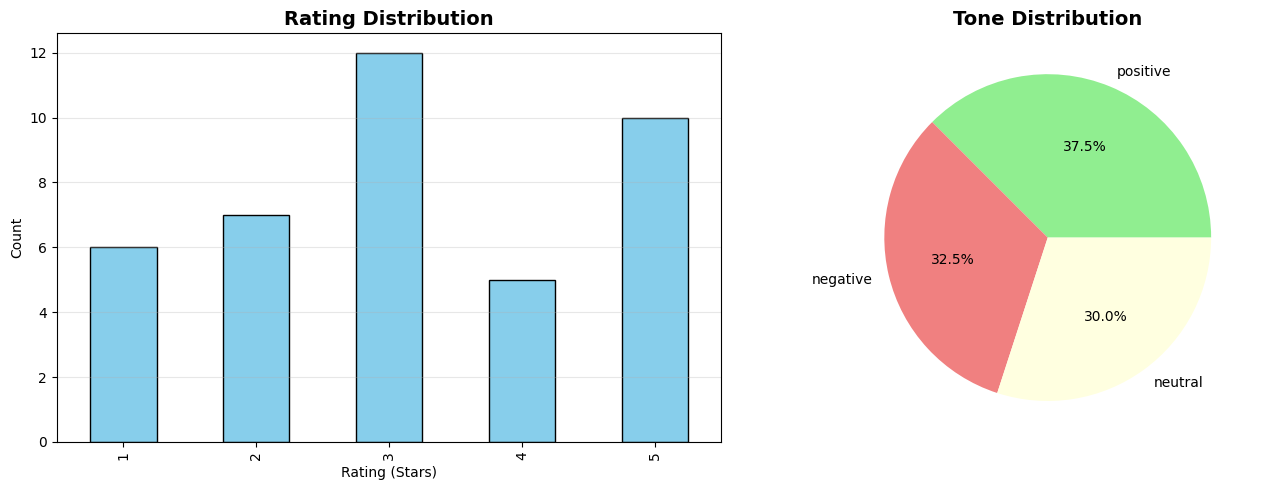


📝 SAMPLE REVIEWS BY RATING

⭐ Rating: 5/5 | Product: Smartphone
Review: It's a good phone. It's a good phone. It's a good phone. It's a good phone. It's a good phone. It's a good phone. It's a good phone. It's a good phone. It's a good phone. It's a good phone.
----------------------------------------------------------------------

⭐ Rating: 3/5 | Product: Smartphone
Review: It's a good phone, but it's a little pricey for what it's worth. If you're looking for a smartphone that's easy to use and has a lot of features, then this is the phone for you. If you're looking for a smartphone that's easy to use and has a lot of features, then this
----------------------------------------------------------------------

⭐ Rating: 1/5 | Product: Laptop
Review: It's a bad laptop. It's a bad laptop. It's a bad laptop. It's a bad laptop. It's a bad laptop. It's a bad laptop. It's a bad laptop. It's a bad laptop. It's a bad laptop. It's a bad laptop.
--------------------------------------------------

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
df['rating'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating (Stars)')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Tone distribution
df['tone'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightcoral', 'lightyellow']
)
axes[1].set_title('Tone Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Show sample reviews by rating
print("\n" + "=" * 70)
print("📝 SAMPLE REVIEWS BY RATING")
print("=" * 70)

for rating in [5, 3, 1]:
    sample = df[df['rating'] == rating].iloc[0]
    print(f"\n⭐ Rating: {rating}/5 | Product: {sample['product']}")
    print(f"Review: {sample['review']}")
    print("-" * 70)

## 🎲 Part 5: Export Data
Exporting the generated data into CSV and Json and downloading the files from Colab


In [10]:
# Export to CSV
csv_filename = "synthetic_reviews.csv"
df.to_csv(csv_filename, index=False)
print(f"✅ Saved to CSV: {csv_filename}")

# Export to JSON
json_filename = "synthetic_reviews.json"
df.to_json(json_filename, orient='records', indent=2)
print(f"✅ Saved to JSON: {json_filename}")

# Download files from Colab
from google.colab import files

print("\n📥 Downloading files...")
files.download(csv_filename)
files.download(json_filename)

print("\n✅ Files downloaded successfully!")

✅ Saved to CSV: synthetic_reviews.csv
✅ Saved to JSON: synthetic_reviews.json

📥 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Files downloaded successfully!


## 🎲 Part 6: Generate Other Data Types
Generating Q&A datasets

*   List item
*   List item



In [ ]:
# Q&A Template
def create_qa_prompt(topic, difficulty="medium"):
    """Generate Q&A pairs"""
    prompt = f"Generate a {difficulty} difficulty question and answer about {topic}."
    return prompt

# Product Description Template
def create_description_prompt(product, features):
    """Generate product descriptions"""
    prompt = f"Write a marketing description for a {product} with these features: {features}."
    return prompt


# Generate Q&A dataset
print("📚 Generating Q&A Pairs...")
print("=" * 70)

qa_data = []
topics = ["Python programming", "Machine Learning", "Data Science", "Web Development"]

for topic in topics:
    for difficulty in ["easy", "medium", "hard"]:
        prompt = create_qa_prompt(topic, difficulty)
        result = generator(prompt, max_new_tokens=100, temperature=0.7, do_sample=True)

        qa_data.append({
            "topic": topic,
            "difficulty": difficulty,
            "qa_pair": result[0]['generated_text']
        })

df_qa = pd.DataFrame(qa_data)
print(df_qa.head(10))

# Save Q&A data
df_qa.to_csv("synthetic_qa_pairs.csv", index=False)
print("\n✅ Q&A pairs saved!")